In [2]:
# import libraries
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")

import os
SEED=56789
import numpy as np
np.random.seed(SEED)
import random as python_random
python_random.seed(SEED)
os.environ['PYTHONHASHSEED']=str(SEED)
import pandas as pd 
from catboost import CatBoostClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score, train_test_split, GridSearchCV
from sklearn import metrics
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, make_scorer
from sklearn.metrics import roc_curve, confusion_matrix, auc, plot_precision_recall_curve, average_precision_score, precision_recall_curve
import tensorflow as tf

from numpy import mean
from numpy import absolute
from numpy import std
from collections import Counter
import itertools

import matplotlib.pyplot as plt
import shap
import seaborn as sns

In [3]:
df = pd.read_csv('GPCR_Opt_ICHEM_FuzCav_Ligand_3Class.csv')
df.head()

,PDB_ID,poc_bit2,poc_bit4,poc_bit5,poc_bit6,poc_bit7,poc_bit9,poc_bit10,poc_bit11,poc_bit15,...,TM_7-7.43_HBond_PROT,TM_7-7.43_Hyd,TM_7-7.44_Hyd,TM_7-7.45_HBond_LIG,TM_7-7.45_Hyd,TM_7-7.46_HBond_PROT,TM_7-7.46_Hyd,TM_7-7.47_Hyd,TM_7-7.53_Hyd,Class
0,1f88,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
1,1gzm,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
2,1hzx,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
3,1jfp,0,0,1,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,1l9h,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1



Classifier Statistics for Test: 
Accuracy_Test: 0.9000
MCC_Test: 0.8321
f1_score_Test: 0.8239
ROC_AUC_Test: 0.8615965553255588
auPR_Test: 0.7577540758461812
Confusion_Matrix_Test: [[31  0  2]
 [ 0  4  5]
 [ 1  0 37]]
              precision    recall  f1-score   support

           0       0.97      0.94      0.95        33
           1       1.00      0.44      0.62         9
           2       0.84      0.97      0.90        38

    accuracy                           0.90        80
   macro avg       0.94      0.79      0.82        80
weighted avg       0.91      0.90      0.89        80



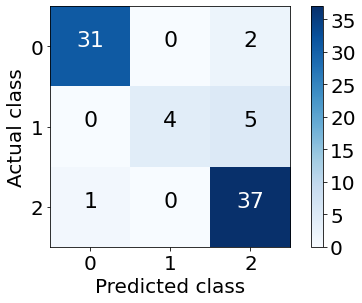

In [4]:
estimator = CatBoostClassifier(iterations=1000, learning_rate=0.5,random_state=123,
                               verbose=False, allow_writing_files=False)
       
X_w = df.iloc[:,0:-1]
y_w = df.iloc[:,-1]
    
X_train_w, X_test_w, y_train, y_test = train_test_split(X_w, y_w, test_size=0.2, random_state=5678, stratify=y_w)

X_train = X_train_w.iloc[:,1:-1]
X_test = X_test_w.iloc[:,1:-1]
X_train_id = X_train_w.iloc[:,0] 
X_test_id = X_test_w.iloc[:,0]   
    
model_TRTS = estimator
model_TRTS.fit(X_train, y_train)
    
y_pred_train = model_TRTS.predict(X_train)
y_pred_test = model_TRTS.predict(X_test)

y_pred_train_df = pd.DataFrame(y_pred_train, columns = ['Pred'])
y_train_df = pd.DataFrame(y_train, columns = ['Class'])
y_train_df = y_train_df.reset_index()
X_train_id = X_train_id.reset_index()
df_train_idx = pd.merge(X_train_id, y_train_df, how='inner', left_index=True, right_index=True)
df_out_train = pd.merge(df_train_idx, y_pred_train_df, how='inner', left_index=True, right_index=True)
    
y_pred_test_df = pd.DataFrame(y_pred_test, columns = ['Pred'])
y_test_df = pd.DataFrame(y_test, columns = ['Class'])
y_test_df = y_test_df.reset_index()
X_test_id = X_test_id.reset_index()
df_test_idx = pd.merge(X_test_id, y_test_df, how='inner', left_index=True, right_index=True)
df_out_test = pd.merge(df_test_idx, y_pred_test_df, how='inner', left_index=True, right_index=True)

acc_ts = accuracy_score(y_test, y_pred_test)
mcc_ts = metrics.matthews_corrcoef(y_test, y_pred_test)
f1_score_ts = metrics.f1_score(y_test, y_pred_test, average='macro')
ytests = tf.keras.utils.to_categorical(np.array(y_test), num_classes=3)
ytest_preds = tf.keras.utils.to_categorical(np.array(y_pred_test), num_classes=3)
roc_auc_ts = metrics.roc_auc_score(ytests, ytest_preds, average='macro',multi_class='ovr')

auPR_ts = average_precision_score(ytests, ytest_preds, average='macro')
cm_ts = confusion_matrix(y_test, y_pred_test)
   
print();print('Classifier Statistics for Test: ')
print("Accuracy_Test: %.4f" % acc_ts)
print("MCC_Test: %.4f" % mcc_ts)
print("f1_score_Test: %.4f" % f1_score_ts)
print("ROC_AUC_Test:", roc_auc_ts)
print("auPR_Test:", auPR_ts)
print("Confusion_Matrix_Test:", cm_ts)
print(classification_report(y_test, y_pred_test))

def plot_confusion_matrix(cm, classes, normalize=False, cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    cb = plt.colorbar()
    for t in cb.ax.get_yticklabels():
        t.set_fontsize(20)
    tick_marks = np.arange(len(classes)) 
    plt.xticks(tick_marks, classes, rotation=0, fontsize=20)
    plt.yticks(tick_marks, classes, fontsize=20)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 fontsize=22,
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('Actual class', fontsize=20)
    plt.xlabel('Predicted class', fontsize=20)
    
cm = confusion_matrix(y_test, y_pred_test)
plot_confusion_matrix(cm, classes = range(3))

In [5]:
pd.set_option('display.max_rows', 500)
df_out_test.head(500)

,index_x,PDB_ID,index_y,Class,Pred
0,2,1hzx,2,1,1
1,308,6rz9,308,2,2
2,73,4ea3,73,2,2
3,9,2i35,9,1,1
4,315,6tot,315,2,2
5,244,6iql,244,2,2
6,175,5wqc,175,2,2
7,188,5zbq,188,2,2
8,15,2y00,15,0,0
9,268,6me4,268,0,0


In [6]:
pd.set_option('display.max_rows', 500)
df_out_train.head(500)

,index_x,PDB_ID,index_y,Class,Pred
0,302,6rz4,302,2,2
1,151,5om4,151,2,2
2,290,6ps3,290,2,2
3,78,4iar,78,0,0
4,145,5olg,145,2,2
5,91,4pxz,91,0,0
6,7,2g87,7,0,0
7,316,6tp3,316,2,2
8,377,7fih,377,0,0
9,312,6to7,312,2,2


In [7]:
catb_explainer = shap.TreeExplainer(model_TRTS)
shap_values_tr = catb_explainer.shap_values(X_train)
shap_values_ts = catb_explainer.shap_values(X_test)

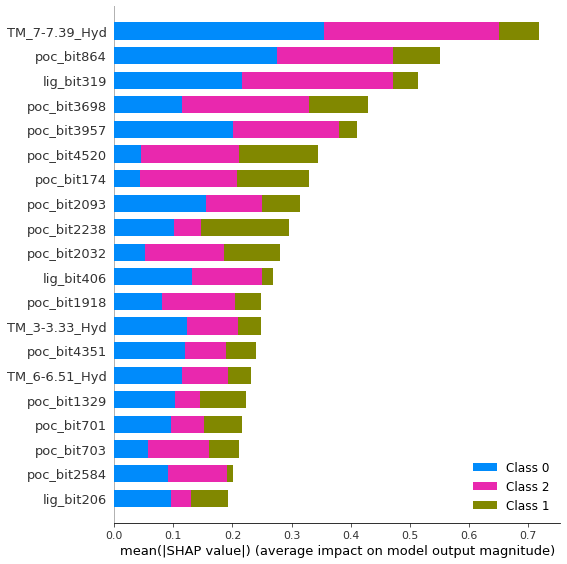

In [8]:
shap.summary_plot(shap_values_tr, X_train, show=False)
# plt.savefig('summary_plot_multiclass_train.jpeg', format = "jpeg", dpi = 600,bbox_inches = 'tight')

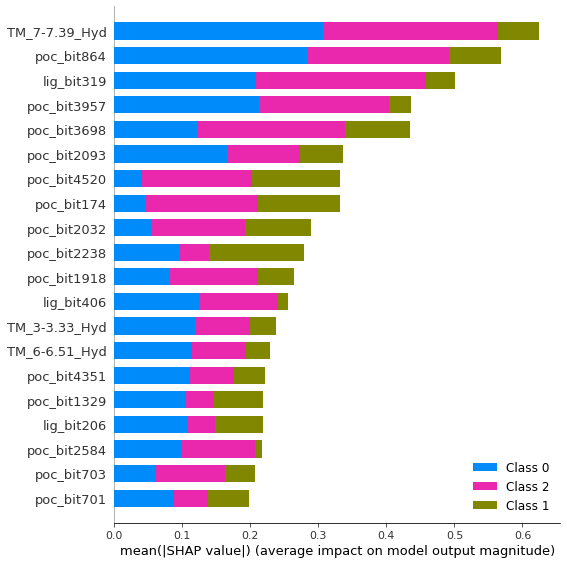

In [9]:
shap.summary_plot(shap_values_ts, X_test, show=False)
# plt.savefig('summary_plot_multiclass_test.jpeg', format = "jpeg", dpi = 600,bbox_inches = 'tight')

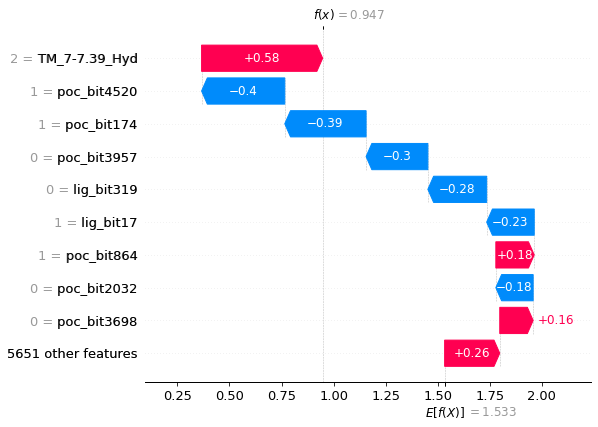

In [10]:
row = 28
class_id = 2
shap.waterfall_plot(shap.Explanation(values=shap_values_ts[class_id][row],
                                     base_values=catb_explainer.expected_value[class_id],
                                     data=X_test.iloc[row],
                                     feature_names=X_test.columns), show=False)
# plt.savefig('WATERFALL_PLOT_OPT_5TGZ_CLASS_2.jpeg', format = "jpeg", dpi = 300, bbox_inches = 'tight')